# Read config

In [1]:
import os 
import configparser
config_path = "configs/Training_config.ini"
config_read = configparser.ConfigParser()
config_read.read(config_path)
for sect in config_read.sections():
    print('Title:', sect)
    for k,v in config_read.items(sect):
        print(' {} = {}'.format(k,v))
    print()

Title: TrainingInfo
 traindataset = ['jaadbeh_with_c_g/train/']
 loss = BCE
 save_model_folder_acc = training_results/best_val_acc/
 save_model_folder_f1 = training_results/best_val_f1/
 batch_size = 100
 stratifiedkfold_random_state = 1
 graph_seed = 2676
 1dcnn_seed = 2726



In [2]:
import json
train_folder = json.loads(config_read.get("TrainingInfo", "traindataset").replace("'",'"'))
loss_name = config_read.get("TrainingInfo", "loss")
save_model_folder_acc = config_read.get("TrainingInfo", "save_model_folder_acc")
save_model_folder_f1 = config_read.get("TrainingInfo", "save_model_folder_f1")
batch_size = int(config_read.get("TrainingInfo", "batch_size"))
ran_2 = int(config_read.get("TrainingInfo", "stratifiedkfold_random_state"))

In [3]:
train_folder

['jaadbeh_with_c_g/train/']

# Load training data 

In [4]:
import os
import numpy as np
root = 'preprocessed_data/jaadbeh_with_c_g/test/'
x_c_test, y_c_test = np.load(root + 'x_c.npy'), np.load(root + 'y.npy')
x_g_test = np.load(root + 'x_g.npy')
print(x_c_test.shape, x_g_test.shape, y_c_test.shape)

(18790, 16, 2) (18790, 2) (18790, 1)


# evaluate 5-fold models on untouched testset

In [5]:
from models.stacked_gru_16frames import *


In [6]:
import torch

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# x1_test = x_c_test[:, :, 3:]#get rid off human reaction 
x1_test = x_c_test
x2_test = x_g_test
y_test = y_c_test


print(x1_test.shape, x2_test.shape)

(18790, 16, 2) (18790, 2)


# ablation analysis

________________________________________
start evaluating fold: 1
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(x2)
/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

Confusion martrix: 


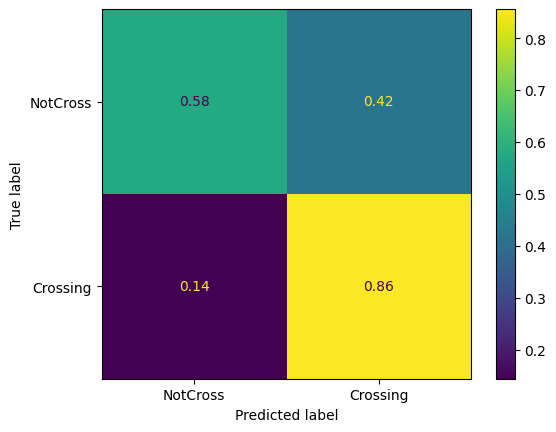

________________________________________
start evaluating fold: 2
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])
Confusion martrix: 


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(x2)
/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

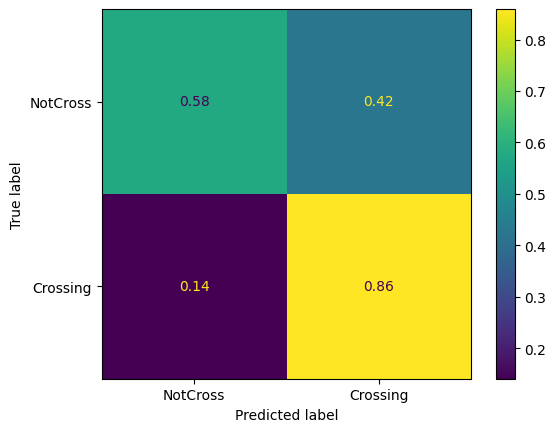

________________________________________
start evaluating fold: 3
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])
Confusion martrix: 


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(x2)
/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

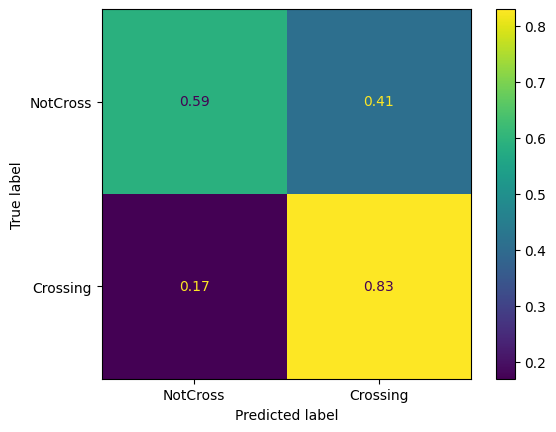

________________________________________
start evaluating fold: 4


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(x2)
/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])
Confusion martrix: 


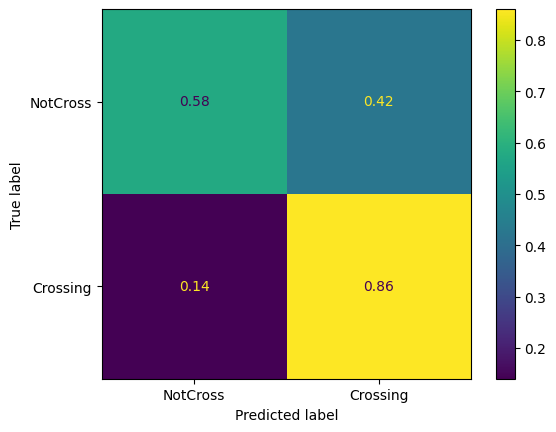

________________________________________
start evaluating fold: 5
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(x2)
/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

Confusion martrix: 


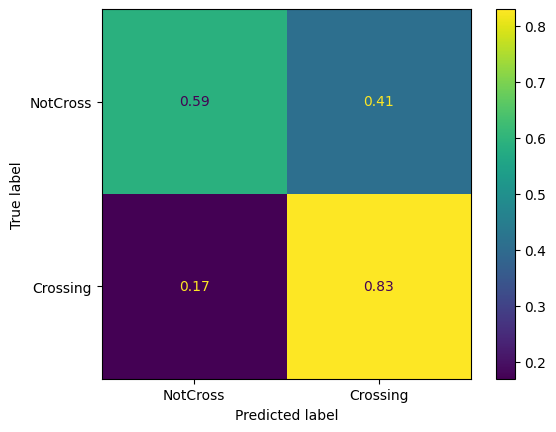

Averaging scores for all folds stats: 
avg_acc: 0.70
avg_auc: 0.77
avg_f1: 0.70
avg_pr: 0.72
avg_re: 0.72


In [8]:
import numpy as np
from model_evaluation.performance_scores import *
from sklearn.metrics import confusion_matrix
from model_evaluation.model_predictions import predict_gru
from model_evaluation.performance_scores import get_precision_recall_F1, calculate_acc
from sklearn import metrics
import matplotlib.pyplot as plt
# from sklearn.metrics import f1_score

k = 5
avg_pr = []
avg_re = []
avg_f1 = []

avg_auc = []
avg_acc = []

model_folder = "best_val_f1/"
preds_li = []
y_li = []
probs_li =[]

# y_test = y_test.cpu().numpy()
# if torch.cuda.is_available():
#     device = torch.device('cuda')
# else:
#     device = torch.device('cpu')

x1_data_sizes = [(16, 1), (16, 1)] 
x2_data_size = x2_test.shape

for i in range(k):
    print('_'*40)
    print('start evaluating fold: {0}'.format(i+1))
    sub_model_folder = model_folder+'fold_{0}/'.format(i+1)
    FC_outputs = predict_gru(x1_data_sizes, x2_data_size, sub_model_folder, x1_test, x2_test, device, 'f1')#FC_outputs: outputs of the last FC
    probs = torch.sigmoid(FC_outputs).cpu().detach()
    preds = torch.round(probs)
    preds = preds.numpy()
    if not type(y_test)== np.ndarray:
        y_test = y_test.cpu().detach().numpy()
    acc= calculate_acc(preds, y_test)
    p, r, f1, auc = get_precision_recall_F1(preds=preds, targets=y_test, probs=probs)
    acc = calculate_acc(preds, y_test)
    avg_pr.append(float(p))
    avg_re.append(float(r))
    avg_f1.append(float(f1))
    avg_auc.append(float(auc))
    avg_acc.append(acc)   
    
    print('Confusion martrix: ')
    # preds = preds.astype(int)
    preds_li.extend(np.squeeze(preds).tolist())
    probs_li.extend(np.squeeze(probs).tolist())
    y_li.extend(y_test.tolist())
    
    confusion_matrix = metrics.confusion_matrix(y_test,preds, normalize='true')
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['NotCross', 'Crossing'])
    cm_display.plot()
    plt.show()

    
    
    
print('='*40)
print('Averaging scores for all folds stats: ')
print("avg_acc: {:.2f}".format(sum(avg_acc)/len(avg_acc)))
print('avg_auc: {:.2f}'.format(sum(avg_auc)/len(avg_auc))) 
print('avg_f1: {:.2f}'.format(sum(avg_f1)/len(avg_f1)))
print('avg_pr: {:.2f}'.format(sum(avg_pr)/len(avg_pr)))
print('avg_re: {:.2f}'.format(sum(avg_re)/len(avg_re)))  


In [9]:
print(len(y_li) == len(preds_li) == len(probs_li))

True


In [10]:
import json
with open('JAADbeh_results.json', 'r') as f:
    results = json.load(f)

In [11]:
results['x2'] = {'probs':probs_li, 'preds': preds_li, 'test_gts': y_li}
# with open('JAADbeh_results.json', 'w') as f:
#     json.dump(results, f)

In [12]:
with open('JAADbeh_results.json', 'w') as f:
    json.dump(results, f)

In [13]:
results.keys()

dict_keys(['x3', 'x1', 'x2'])